# Static–dynamic split-half RSA — transparent workflow

Every analysis step is shown explicitly below. We load the individual repetitions, split repetitions independently within each stimulus, compute raw-response and RDM split-half consistency, and compare dynamic RDMs with static RDMs.

In [4]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.stats import rankdata

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config.yaml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find config.yaml above the notebook directory.")
    # end if PROJECT_ROOT.parent == PROJECT_ROOT
    PROJECT_ROOT = PROJECT_ROOT.parent
# end while not config.yaml exists
with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open
paths = config[ENV]["paths"]
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from project_specific_utils import load_raster
from useful_stuff.general_utils import TimeSeries, create_RDM


In [50]:
@dataclass
class Cfg:
    static_exp_name: str = "red_20260726to27" # "baby1_260718to27" # 
    dynamic_exp_name: str = "red_20260720to24"  #"baby1_260716to24" # 
    # Inclusive, one-based MATLAB channel range.
    good_channels: tuple[int, int] | None = None #(101, 109)
    # Used only when good_channels is None; ranked by maximum video response.
    top_k: int | None = 50
    static_crop_ms: float = 1000
    static_response: str = "2000ms"  # last_frame, 2000ms, or 2250ms
    dynamic_crop_ms: float | None = None
    source_fs: float = 1000
    new_fs: float = 100
    rdm_metric: str = "cosine_cnt"
    rsa_metric: str = "correlation"
    n_split_repeats: int = 10
    random_seed: int = 0
    static_reference_window_ms: tuple[float, float] = (0, 1000)

cfg = Cfg()
valid_static_responses = {"last_frame", "2000ms", "2250ms"}
if cfg.static_response not in valid_static_responses:
    raise ValueError(f"static_response must be one of {sorted(valid_static_responses)}.")
# end if cfg.static_response
data_dir = Path(paths["data_path"]) / "data"
static_path = data_dir / f"{cfg.static_exp_name}_raster_img.mat"
dynamic_path = data_dir / f"{cfg.dynamic_exp_name}_raster_vid.mat"
if cfg.good_channels is None:
    channel_slice = slice(None)
else:
    first_channel, last_channel = cfg.good_channels
    channel_slice = slice(first_channel - 1, last_channel)
# end if cfg.good_channels
static_end_sample = int(round(cfg.static_crop_ms * cfg.source_fs / 1000))
dynamic_end_sample = None if cfg.dynamic_crop_ms is None else int(round(cfg.dynamic_crop_ms * cfg.source_fs / 1000))
cfg


Cfg(static_exp_name='red_20260726to27', dynamic_exp_name='red_20260720to24', good_channels=None, top_k=50, static_crop_ms=1000, static_response='2000ms', dynamic_crop_ms=None, source_fs=1000, new_fs=100, rdm_metric='cosine_cnt', rsa_metric='correlation', n_split_repeats=10, random_seed=0, static_reference_window_ms=(0, 1000))

## 1. Load individual repetitions

Unlike `natraster`, the `raster` files retain repeated presentations. This is what makes a genuine split-half analysis possible.

In [51]:
static_rasters, static_names = load_raster(
    static_path, channel_slice=channel_slice, end_sample=static_end_sample,
)
dynamic_rasters, dynamic_names = load_raster(
    dynamic_path, channel_slice=channel_slice, end_sample=dynamic_end_sample,
)
print(f"Static raster: {static_rasters.shape}")
print(f"Dynamic raster: {dynamic_rasters.shape}")
print(f"Example static names: {static_names[:3]}")
print(f"Example dynamic names: {dynamic_names[:3]}")


Static raster: (64, 1000, 4545)
Dynamic raster: (64, 3500, 3625)
Example static names: ['img_2250ms_monkeys_n_apes11.jpg', 'img_peacocks_4k1.jpg', 'img_2250ms_wild_dramas1.jpg']
Example dynamic names: ['vid_watch_these_adorable_monkeys1.mp4', 'vid_monkeys_n_apes3.mp4', 'vid_this_is_how_monkey_eat2.mp4']


## 2. Match standard static and dynamic stimuli

The selected static response can be the last-frame image (`last_frame`), the 2000 ms control, or the 2250 ms control. The identity is the filename after the condition-specific prefix. When `good_channels=None` and `top_k` is set, channels are ranked by their maximum raw response across matched dynamic presentations, and the same selected channels are used for both conditions.

In [52]:
"""
stimulus_identity
Extract a stimulus identity while retaining only the configured static response.

INPUT:
    - name: str -> presentation filename
    - condition: str -> static or dynamic

OUTPUT:
    - identity: str | None -> matched identity, or None for an excluded presentation
"""
def stimulus_identity(name, condition, static_response=cfg.static_response):
    stem = Path(name).stem
    if condition == "static":
        static_prefixes = {
            "last_frame": "img_",
            "2000ms": "img_2000ms_",
            "2250ms": "img_2250ms_",
        }
        if stem.startswith(static_prefixes["2000ms"]):
            response = "2000ms"
        elif stem.startswith(static_prefixes["2250ms"]):
            response = "2250ms"
        elif stem.startswith(static_prefixes["last_frame"]):
            response = "last_frame"
        else:
            return None
        # end if static filename prefix
        if response != static_response:
            return None
        # end if response != static_response
        prefix = static_prefixes[response]
    elif condition == "dynamic":
        prefix = "vid_"
    else:
        raise ValueError("condition must be 'static' or 'dynamic'.")
    # end if condition
    return stem[len(prefix):] if stem.startswith(prefix) else None
# EOF

static_ids = [stimulus_identity(name, "static") for name in static_names]
dynamic_ids = [stimulus_identity(name, "dynamic") for name in dynamic_names]
shared_stimuli = sorted(
    {identity for identity in static_ids if identity is not None}
    & {identity for identity in dynamic_ids if identity is not None}
)
if len(shared_stimuli) < 3:
    raise ValueError("Need at least three shared stimuli.")
# end if len(shared_stimuli)
shared_set = set(shared_stimuli)
static_keep = np.array([identity in shared_set for identity in static_ids])
dynamic_keep = np.array([identity in shared_set for identity in dynamic_ids])
static_rasters = static_rasters[:, :, static_keep]
dynamic_rasters = dynamic_rasters[:, :, dynamic_keep]
static_ids = [identity for identity, keep in zip(static_ids, static_keep) if keep]
dynamic_ids = [identity for identity, keep in zip(dynamic_ids, dynamic_keep) if keep]

# Select channels only after the static and dynamic presentations are matched.
selected_excitation_scores = None
if cfg.good_channels is not None:
    first_channel, last_channel = cfg.good_channels
    channel_numbers = np.arange(first_channel, last_channel + 1)
    channel_selection_description = f"MATLAB channels {first_channel}-{last_channel}"
elif cfg.top_k is not None:
    if not isinstance(cfg.top_k, int) or isinstance(cfg.top_k, bool):
        raise TypeError("top_k must be an integer or None.")
    # end if cfg.top_k type
    n_available_channels = dynamic_rasters.shape[0]
    if not 1 <= cfg.top_k <= n_available_channels:
        raise ValueError(
            f"top_k must be between 1 and {n_available_channels}, got {cfg.top_k}."
        )
    # end if cfg.top_k range

    # Rank channels by their maximum raw response across matched videos.
    channel_excitation_scores = dynamic_rasters.max(axis=(1, 2))
    channel_indices = np.argsort(channel_excitation_scores)[-cfg.top_k:][::-1]
    selected_excitation_scores = channel_excitation_scores[channel_indices]
    static_rasters = static_rasters[channel_indices]
    dynamic_rasters = dynamic_rasters[channel_indices]
    channel_numbers = channel_indices + 1
    channel_selection_description = f"top {cfg.top_k} video-responsive channels"
else:
    channel_numbers = np.arange(1, dynamic_rasters.shape[0] + 1)
    channel_selection_description = "all available channels"
# end if cfg.good_channels is not None
print(f"Shared stimuli: {len(shared_stimuli)}")
print(f"Retained static presentations: {static_rasters.shape[2]}")
print(f"Retained dynamic presentations: {dynamic_rasters.shape[2]}")
print(f"Channel selection: {channel_selection_description}")
print(f"MATLAB channels: {channel_numbers.tolist()}")
if selected_excitation_scores is not None:
    print(f"Selected maximum video responses: {selected_excitation_scores.tolist()}")
# end if selected_excitation_scores is not None


Shared stimuli: 100
Retained static presentations: 1517
Retained dynamic presentations: 3625
Channel selection: top 50 video-responsive channels
MATLAB channels: [64, 21, 38, 37, 35, 33, 31, 30, 29, 26, 25, 19, 40, 18, 14, 11, 10, 7, 6, 5, 4, 3, 39, 32, 1, 51, 62, 61, 45, 60, 55, 49, 57, 56, 58, 2, 16, 15, 13, 9, 12, 54, 8, 59, 17, 41, 53, 42, 43, 44]
Selected maximum video responses: [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.9800000190734863, 1.9600000381469727, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## 3. Resample and define visible numerical helpers

In [53]:
def resample_rasters(rasters, source_fs, target_fs):
    if source_fs == target_fs:
        return rasters
    # end if source_fs == target_fs
    series = TimeSeries(rasters, fs=source_fs)
    series.resample(target_fs)
    return series.get_array()
# EOF

static_rasters = resample_rasters(static_rasters, cfg.source_fs, cfg.new_fs)
dynamic_rasters = resample_rasters(dynamic_rasters, cfg.source_fs, cfg.new_fs)
static_times_ms = np.arange(static_rasters.shape[1]) * 1000 / cfg.new_fs
dynamic_times_ms = np.arange(dynamic_rasters.shape[1]) * 1000 / cfg.new_fs

def split_repetitions(rasters, identities, stimulus_order, rng):
    """Split and average repetitions separately for every stimulus."""
    indices_by_identity = {}
    for presentation_index, identity in enumerate(identities):
        indices_by_identity.setdefault(identity, []).append(presentation_index)
    # end for presentation_index, identity
    first_means, second_means = [], []
    for identity in stimulus_order:
        indices = np.asarray(indices_by_identity[identity], dtype=int)
        if len(indices) < 2:
            raise ValueError(f"{identity!r} has fewer than two repetitions.")
        # end if len(indices)
        indices = rng.permutation(indices)
        split_index = len(indices) // 2
        first_means.append(rasters[:, :, indices[:split_index]].mean(axis=2))
        second_means.append(rasters[:, :, indices[split_index:]].mean(axis=2))
    # end for identity
    return np.stack(first_means, axis=2), np.stack(second_means, axis=2)
# EOF

def row_correlation(first, second, metric="correlation"):
    """Correlate matching rows, optionally after ranking each row."""
    if metric == "spearman":
        first, second = rankdata(first, axis=1), rankdata(second, axis=1)
    elif metric != "correlation":
        raise ValueError("metric must be correlation or spearman.")
    # end if metric
    first = first - first.mean(axis=1, keepdims=True)
    second = second - second.mean(axis=1, keepdims=True)
    numerator = np.sum(first * second, axis=1)
    denominator = np.linalg.norm(first, axis=1) * np.linalg.norm(second, axis=1)
    output = np.full(first.shape[0], np.nan)
    np.divide(numerator, denominator, out=output, where=denominator > 0)
    return np.clip(output, -1, 1)
# EOF

def rdm_timeseries(rasters, metric):
    """Build one condensed stimulus RDM for every timepoint."""
    return np.stack([
        create_RDM(rasters[:, time_index, :], metric=metric)
        for time_index in range(rasters.shape[1])
    ])
# EOF

def cross_temporal_correlation(first, second, metric="correlation"):
    """Correlate every row of first with every row of second."""
    if metric == "spearman":
        first, second = rankdata(first, axis=1), rankdata(second, axis=1)
    elif metric != "correlation":
        raise ValueError("metric must be correlation or spearman.")
    # end if metric
    first = first - first.mean(axis=1, keepdims=True)
    second = second - second.mean(axis=1, keepdims=True)
    denominator = np.linalg.norm(first, axis=1)[:, None] * np.linalg.norm(second, axis=1)[None, :]
    output = np.full((first.shape[0], second.shape[0]), np.nan)
    np.divide(first @ second.T, denominator, out=output, where=denominator > 0)
    return np.clip(output, -1, 1)
# EOF


## 4. Compute split-half self-consistency

For each random split, raw consistency compares channel × stimulus response vectors. RDM consistency compares the condensed stimulus RDM vectors.

In [54]:
def condition_split_half(rasters, identities, stimulus_order, cfg, rng):
    raw_reliabilities, rdm_reliabilities = [], []
    for repeat_index in range(cfg.n_split_repeats):
        first_half, second_half = split_repetitions(
            rasters, identities, stimulus_order, rng,
        )
        first_raw = first_half.transpose(1, 0, 2).reshape(first_half.shape[1], -1)
        second_raw = second_half.transpose(1, 0, 2).reshape(second_half.shape[1], -1)
        raw_reliabilities.append(row_correlation(first_raw, second_raw))
        first_rdms = rdm_timeseries(first_half, cfg.rdm_metric)
        second_rdms = rdm_timeseries(second_half, cfg.rdm_metric)
        rdm_reliabilities.append(
            row_correlation(first_rdms, second_rdms, cfg.rsa_metric)
        )
        print(f"split {repeat_index + 1}/{cfg.n_split_repeats}")
    # end for repeat_index
    return np.stack(raw_reliabilities), np.stack(rdm_reliabilities)
# EOF

rng = np.random.default_rng(cfg.random_seed)
print("Static condition")
static_raw_split_half, static_rdm_split_half = condition_split_half(
    static_rasters, static_ids, shared_stimuli, cfg, rng,
)
print("Dynamic condition")
dynamic_raw_split_half, dynamic_rdm_split_half = condition_split_half(
    dynamic_rasters, dynamic_ids, shared_stimuli, cfg, rng,
)


Static condition
split 1/10
split 2/10
split 3/10
split 4/10
split 5/10
split 6/10
split 7/10
split 8/10
split 9/10
split 10/10
Dynamic condition
split 1/10
split 2/10
split 3/10
split 4/10
split 5/10
split 6/10
split 7/10
split 8/10
split 9/10
split 10/10


## 5. Compute full-condition RDMs and static–dynamic explanation

In [55]:
def average_by_stimulus(rasters, identities, stimulus_order):
    means = []
    for identity in stimulus_order:
        indices = np.flatnonzero(np.asarray(identities) == identity)
        means.append(rasters[:, :, indices].mean(axis=2))
    # end for identity
    return np.stack(means, axis=2)
# EOF

static_means = average_by_stimulus(static_rasters, static_ids, shared_stimuli)
dynamic_means = average_by_stimulus(dynamic_rasters, dynamic_ids, shared_stimuli)
static_rdms = rdm_timeseries(static_means, cfg.rdm_metric)
dynamic_rdms = rdm_timeseries(dynamic_means, cfg.rdm_metric)

# Rows are dynamic timepoints and columns are static timepoints.
static_dynamic_rdm_similarity = cross_temporal_correlation(
    dynamic_rdms, static_rdms, cfg.rsa_metric,
)
reference_start_ms, reference_end_ms = cfg.static_reference_window_ms
reference_indices = (static_times_ms >= reference_start_ms) & (static_times_ms <= reference_end_ms)
maximum_static_explained_variance = np.nanmax(
    static_dynamic_rdm_similarity[:, reference_indices], axis=1,
)
print(f"RDM matrix: {static_dynamic_rdm_similarity.shape}")
print(f"Best dynamic time: {dynamic_times_ms[np.nanargmax(maximum_static_explained_variance)]:g} ms")


RDM matrix: (350, 100)
Best dynamic time: 2190 ms


## 6. Visualize consistency and static explanation

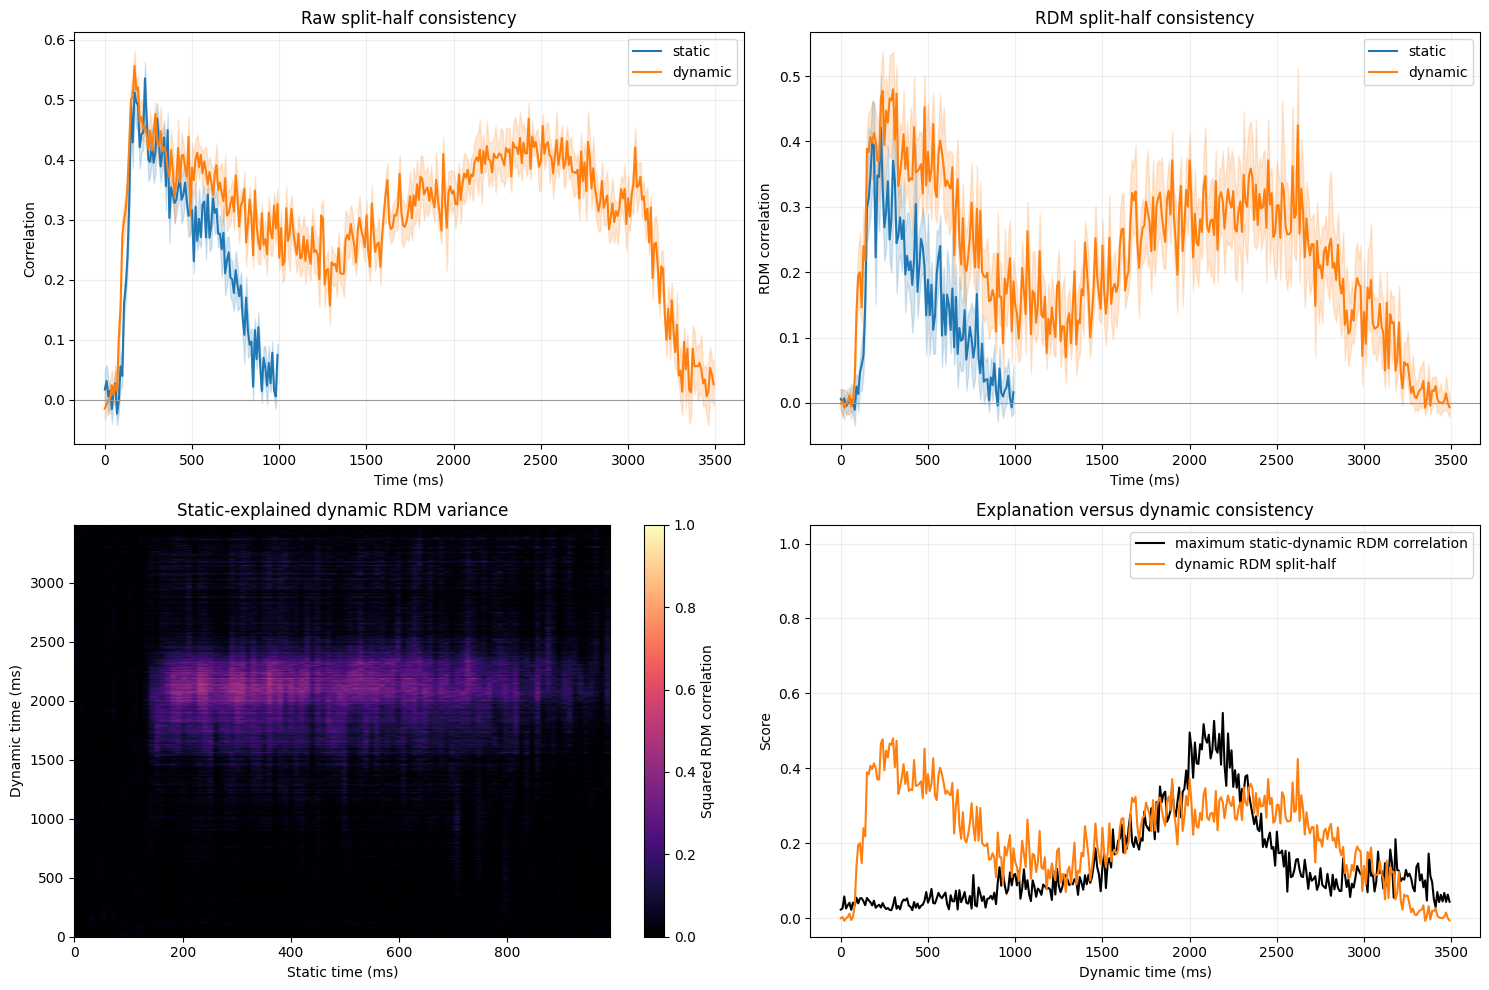

In [56]:
figure, axes = plt.subplots(2, 2, figsize=(15, 10))
for condition, color, times_ms in (("static", "tab:blue", static_times_ms), ("dynamic", "tab:orange", dynamic_times_ms)):
    raw_values = locals()[f"{condition}_raw_split_half"]
    rdm_values = locals()[f"{condition}_rdm_split_half"]
    axes[0, 0].plot(times_ms, raw_values.mean(axis=0), color=color, label=condition)
    axes[0, 1].plot(times_ms, rdm_values.mean(axis=0), color=color, label=condition)
    if cfg.n_split_repeats > 1:
        axes[0, 0].fill_between(times_ms, np.percentile(raw_values, 2.5, axis=0), np.percentile(raw_values, 97.5, axis=0), color=color, alpha=0.18)
        axes[0, 1].fill_between(times_ms, np.percentile(rdm_values, 2.5, axis=0), np.percentile(rdm_values, 97.5, axis=0), color=color, alpha=0.18)
    # end if cfg.n_split_repeats
# end for condition
axes[0, 0].set(title="Raw split-half consistency", xlabel="Time (ms)", ylabel="Correlation")
axes[0, 1].set(title="RDM split-half consistency", xlabel="Time (ms)", ylabel="RDM correlation")
for axis in axes[0]:
    axis.axhline(0, color="0.6", linewidth=0.8)
    axis.legend()
    axis.grid(alpha=0.2)
# end for axis
image = axes[1, 0].imshow(
    static_dynamic_rdm_similarity, origin="lower", aspect="auto", cmap="magma", vmin=0, vmax=1,
    extent=(static_times_ms[0], static_times_ms[-1], dynamic_times_ms[0], dynamic_times_ms[-1]),
)
axes[1, 0].set(title="Static-explained dynamic RDM variance", xlabel="Static time (ms)", ylabel="Dynamic time (ms)")
figure.colorbar(image, ax=axes[1, 0], label="Squared RDM correlation")
axes[1, 1].plot(dynamic_times_ms, maximum_static_explained_variance, color="black", label="maximum static-dynamic RDM correlation")
axes[1, 1].plot(dynamic_times_ms, dynamic_rdm_split_half.mean(axis=0), color="tab:orange", label="dynamic RDM split-half")
axes[1, 1].set(title="Explanation versus dynamic consistency", xlabel="Dynamic time (ms)", ylabel="Score", ylim=(-0.05, 1.05))
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.2)
figure.tight_layout()
plt.show()


/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_4890/1120100082.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout()


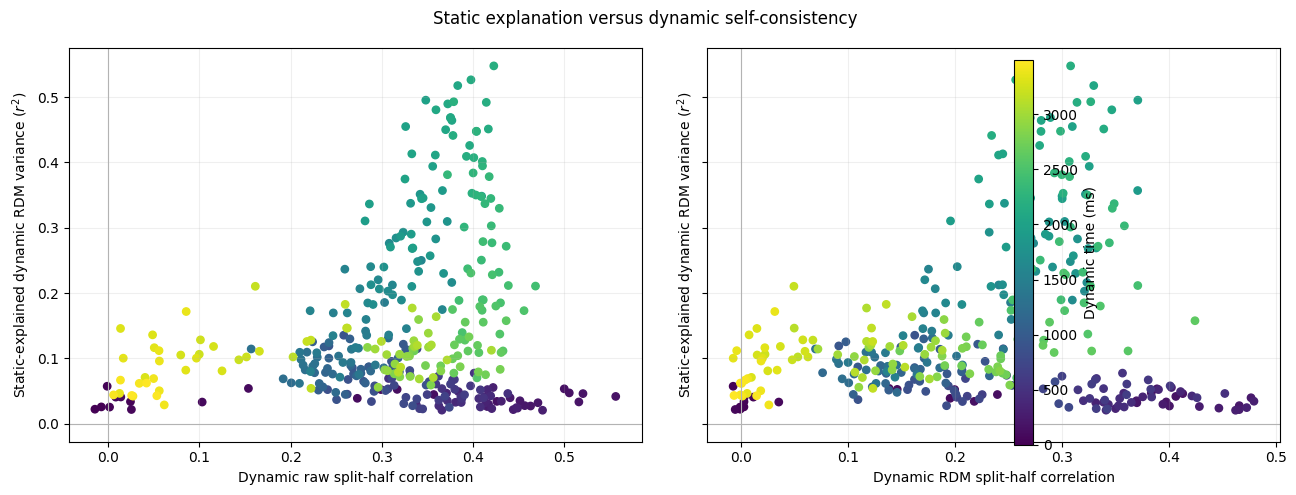

In [57]:
dynamic_raw_mean = dynamic_raw_split_half.mean(axis=0)
dynamic_rdm_mean = dynamic_rdm_split_half.mean(axis=0)
figure, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for axis, consistency, xlabel in zip(
        axes,
        (dynamic_raw_mean, dynamic_rdm_mean),
        ("Dynamic raw split-half correlation", "Dynamic RDM split-half correlation"),
        ):
    points = axis.scatter(consistency, maximum_static_explained_variance, c=dynamic_times_ms, cmap="viridis", s=28)
    axis.set(xlabel=xlabel, ylabel="Static-explained dynamic RDM variance ($r^2$)")
    axis.axhline(0, color="0.7", linewidth=0.8)
    axis.axvline(0, color="0.7", linewidth=0.8)
    axis.grid(alpha=0.2)
# end for axis
figure.colorbar(points, ax=axes, label="Dynamic time (ms)")
figure.suptitle("Static explanation versus dynamic self-consistency")
figure.tight_layout()
plt.show()
